# 📊 Project 8 – Agentic Customer Analytics Assistant
## Notebook 01 – Exploratory Data Analysis (EDA)

In this notebook, we explore the customer analytics dataset used in this project.

Goals:
- Understand the structure and quality of the data
- Identify key customer and transaction features
- Explore distributions, relationships, and basic KPIs
- Prepare a cleaned dataset for modeling and the agentic workflow

In [1]:
# Import & settings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

sns.set(style="whitegrid")

# Notebook metadata
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(PROJECT_ROOT, "data")

PROJECT_ROOT, DATA_DIR

('C:\\Users\\ynalq\\Projects\\Data-portfolio\\project8-agentic-customer-analytics-assistant',
 'C:\\Users\\ynalq\\Projects\\Data-portfolio\\project8-agentic-customer-analytics-assistant\\data')

In [2]:
# Load the dataset
csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith("customer360_raw.csv")]
csv_files

['customer360_raw.csv']

In [3]:
DATA_PATH = os.path.join(DATA_DIR, csv_files[0])  # or replace csv_files[0] with exact name
print(DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.shape, df.dtypes.head()

C:\Users\ynalq\Projects\Data-portfolio\project8-agentic-customer-analytics-assistant\data\customer360_raw.csv


((2000, 23),
 SessionStart    object
 CustomerID       int64
 FullName        object
 Gender          object
 Age              int64
 dtype: object)

In [4]:
df.columns = (
    df.columns
    .str.strip()        # remove leading/trailing spaces
    .str.replace(" ", "")  # remove internal spaces like "Cost Price" → "CostPrice"
)

df.columns.tolist()

['SessionStart',
 'CustomerID',
 'FullName',
 'Gender',
 'Age',
 'CreditScore',
 'MonthlyIncome',
 'Country',
 'State',
 'City',
 'Category',
 'Product',
 'Cost',
 'Price',
 'Quantity',
 'CampaignSchema',
 'CartAdditionTime',
 'OrderConfirmation',
 'OrderConfirmationTime',
 'PaymentMethod',
 'SessionEnd',
 'OrderReturn',
 'ReturnReason']

In [5]:
df.head()

,SessionStart,CustomerID,FullName,Gender,Age,CreditScore,MonthlyIncome,Country,State,City,Category,Product,Cost,Price,Quantity,CampaignSchema,CartAdditionTime,OrderConfirmation,OrderConfirmationTime,PaymentMethod,SessionEnd,OrderReturn,ReturnReason
0,2019-01-01 02:42:00,1001,Brittany Franklin,Male,57,780,7591,China,Guangdong,Dongguan,electronics,table fan,30,50,4,Instagram-ads,2019-01-01 02:49:00,True,2019-01-01 03:02:00,Cash On Delivery,2019-01-01 02:53:00,False,NaN
1,2019-01-02 20:35:00,1002,Scott Stewart,Female,69,746,3912,China,Shandong,Yantai,fashion,dress,50,80,6,Google-ads,2019-01-02 20:50:00,True,2019-01-02 20:58:00,Debit Card,2019-01-02 20:54:00,False,NaN
2,2019-01-04 03:11:00,1003,Elizabeth Fowler,Female,21,772,7460,UK,England,Birmingham,toys,plush toy,12,20,2,Facebook-ads,2019-01-04 03:30:00,True,2019-01-04 03:40:00,Cash On Delivery,2019-01-04 03:35:00,False,NaN
3,2019-01-05 09:01:00,1004,Julian Wall,Female,67,631,4765,UK,England,Birmingham,toys,plush toy,12,20,2,Twitter-ads,2019-01-05 09:17:00,True,2019-01-05 09:26:00,Cash On Delivery,2019-01-05 09:20:00,False,NaN
4,2019-01-05 13:35:00,1005,James Simmons,Male,57,630,3268,China,Shandong,Yantai,fashion,shoes,60,100,6,Billboard-QR code,2019-01-05 13:40:00,True,2019-01-05 13:52:00,Debit Card,2019-01-05 13:42:00,False,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   SessionStart           2000 non-null   object
 1   CustomerID             2000 non-null   int64 
 2   FullName               2000 non-null   object
 3   Gender                 2000 non-null   object
 4   Age                    2000 non-null   int64 
 5   CreditScore            2000 non-null   int64 
 6   MonthlyIncome          2000 non-null   int64 
 7   Country                2000 non-null   object
 8   State                  2000 non-null   object
 9   City                   2000 non-null   object
 10  Category               2000 non-null   object
 11  Product                2000 non-null   object
 12  Cost                   2000 non-null   int64 
 13  Price                  2000 non-null   int64 
 14  Quantity               2000 non-null   int64 
 15  CampaignSchema       

In [7]:
df.describe(include="all").transpose().head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SessionStart,2000,2000,2019-01-01 02:42:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,2000.0,NaN,NaN,NaN,1609.064,349.835233,1001.0,1311.0,1610.0,1915.25,2200.0
FullName,2000,1200,Jacob Sparks,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,2000,2,Female,1016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2000.0,NaN,NaN,NaN,44.4875,16.350367,18.0,31.0,44.0,59.0,72.0
CreditScore,2000.0,NaN,NaN,NaN,690.1265,50.618066,600.0,646.0,691.0,732.0,780.0
MonthlyIncome,2000.0,NaN,NaN,NaN,5589.697,1441.584931,3001.0,4403.5,5656.5,6856.25,7999.0
Country,2000,9,Canada,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,2000,18,Maharashtra,144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,2000,52,Yokohama,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.nunique().sort_values(ascending=False).head(20)

SessionStart             2000
CartAdditionTime         2000
SessionEnd               1999
OrderConfirmationTime    1700
CustomerID               1200
FullName                 1200
MonthlyIncome            1069
CreditScore               180
Age                        55
City                       52
Product                    20
State                      18
Price                      17
Cost                       15
Country                     9
Quantity                    6
CampaignSchema              6
Category                    5
ReturnReason                5
PaymentMethod               4
dtype: int64

In [9]:
# basic data quality & missing values
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

ReturnReason             1764
OrderReturn               300
PaymentMethod             300
OrderConfirmationTime     300
dtype: int64

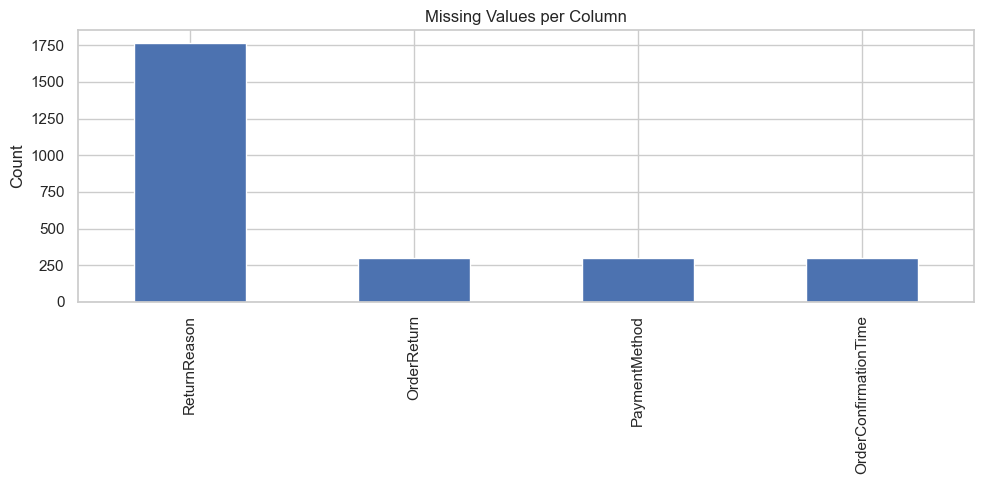

In [10]:
plt.figure(figsize=(10, 5))
missing.plot(kind="bar")
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

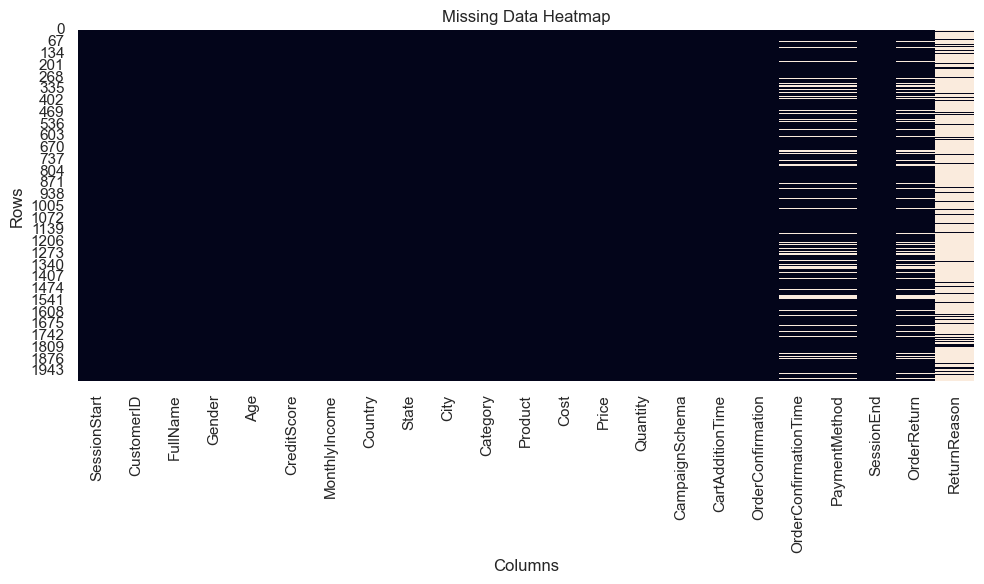

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Data Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

In [12]:
# detect & parse date columns
date_like_cols = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()]
date_like_cols

['CartAdditionTime', 'OrderConfirmationTime']

In [13]:
for col in date_like_cols:
    try:
        df[col] = pd.to_datetime(df[col])
        print(f"Parsed {col} as datetime.")
    except Exception as e:
        print(f"Could not parse {col}: {e}")

Parsed CartAdditionTime as datetime.
Parsed OrderConfirmationTime as datetime.


In [14]:
# categorical vs numerical split
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number, "datetime64[ns]"]).columns.tolist()
datetime_cols = df.select_dtypes(include=["datetime64[ns]"]).columns.tolist()

numeric_cols[:10], categorical_cols[:10], datetime_cols

(['CustomerID',
  'Age',
  'CreditScore',
  'MonthlyIncome',
  'Cost',
  'Price',
  'Quantity'],
 ['SessionStart',
  'FullName',
  'Gender',
  'Country',
  'State',
  'City',
  'Category',
  'Product',
  'CampaignSchema',
  'OrderConfirmation'],
 ['CartAdditionTime', 'OrderConfirmationTime'])

In [15]:
# univariate distribution (numeric)
len(numeric_cols)

7

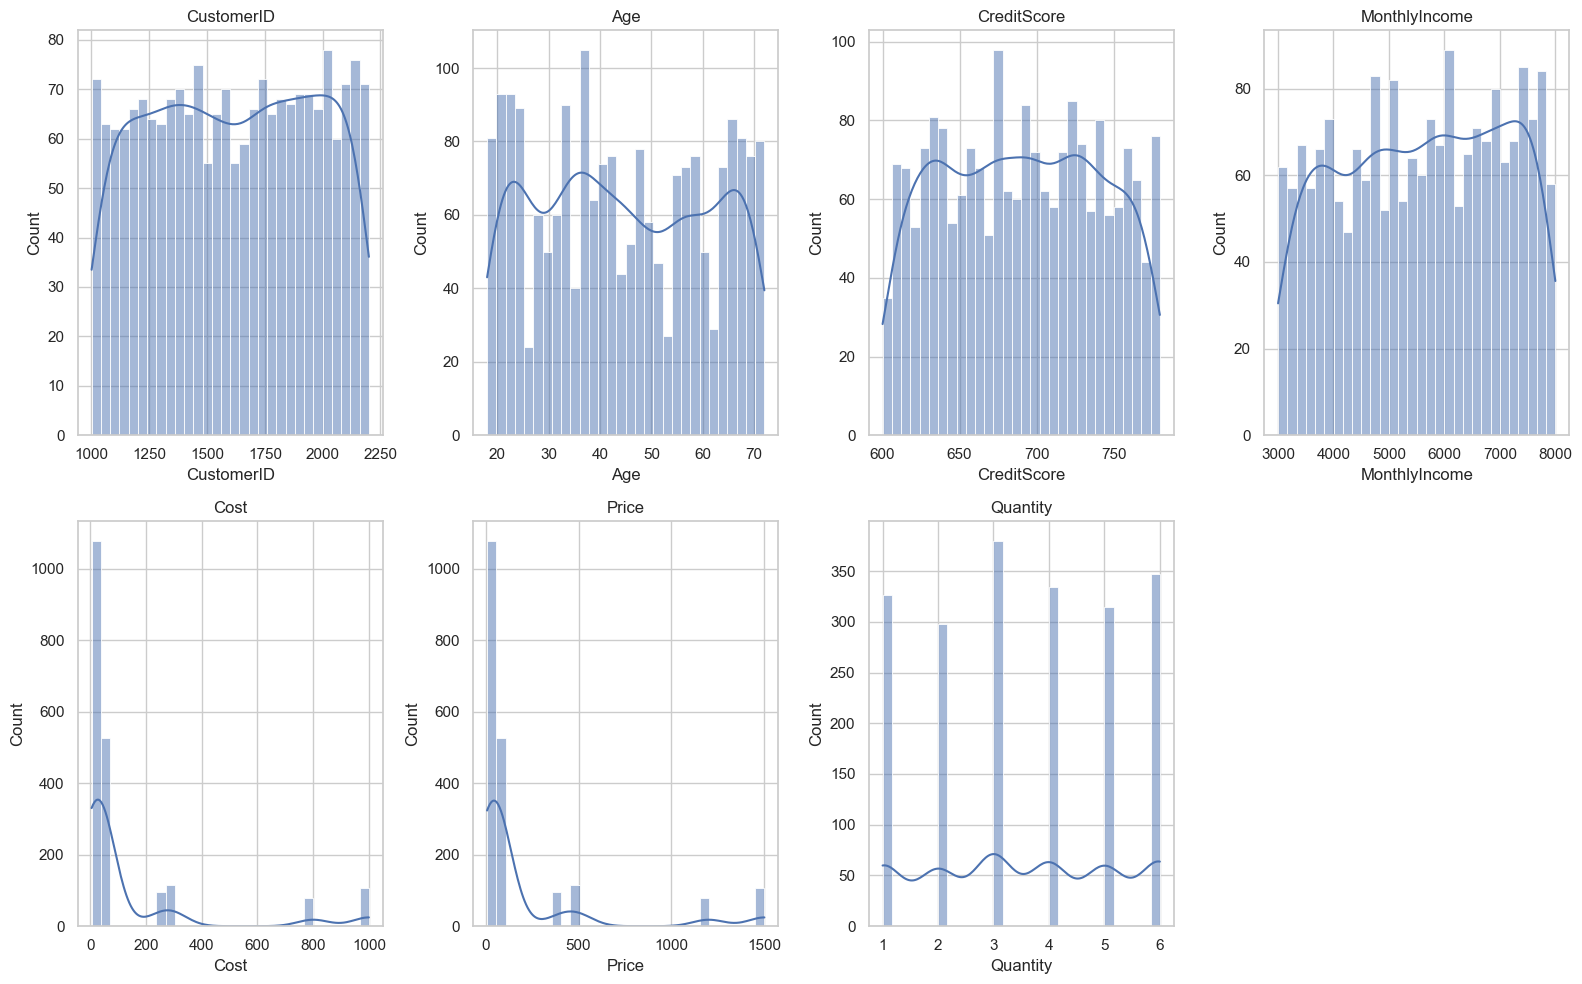

In [16]:
n_to_plot = min(8, len(numeric_cols))

plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols[:n_to_plot], 1):
    plt.subplot(2, 4, i)
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [17]:
numeric_cols = ["Age", "CreditScore", "MonthlyIncome", "Cost", "Price", "Quantity"]

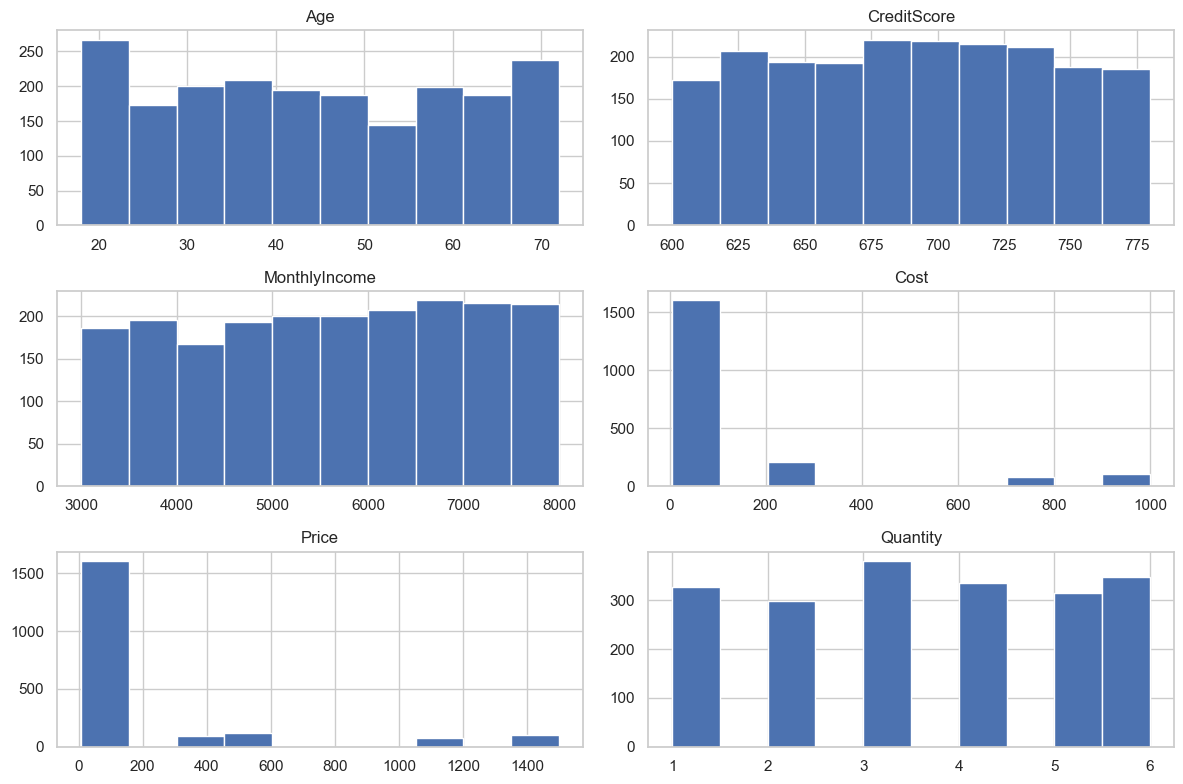

In [18]:
df[numeric_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [19]:
# categorical overview
for col in categorical_cols[:8]:
    display(pd.DataFrame(df[col].value_counts().head(10)).rename(columns={col: "count"}))
    print("-" * 60)

,count
SessionStart,
2019-01-01 02:42:00,1
2022-05-10 02:38:00,1
2022-05-29 05:36:00,1
2022-05-28 08:36:00,1
2022-05-26 15:18:00,1
2022-05-25 20:42:00,1
2022-05-24 20:24:00,1
2022-05-22 00:49:00,1
2022-05-21 11:31:00,1


------------------------------------------------------------


,count
FullName,
Jacob Sparks,5
Troy Wells,5
Crystal Mitchell,4
Thomas Gonzales,4
Catherine Blevins,4
Jessica Santiago,4
Amanda Moreno,4
Marvin Lam,4
Lisa Ross,4


------------------------------------------------------------


,count
Gender,
Female,1016
Male,984


...

------------------------------------------------------------


,count
Category,
home appliances,423
toys,412
books,406
fashion,398
electronics,361


------------------------------------------------------------


,count
Product,
action figure,118
shoes,116
microwave oven,116
magazine,113
puzzle,111
toaster,109
board game,109
jeans,107
television,106


------------------------------------------------------------


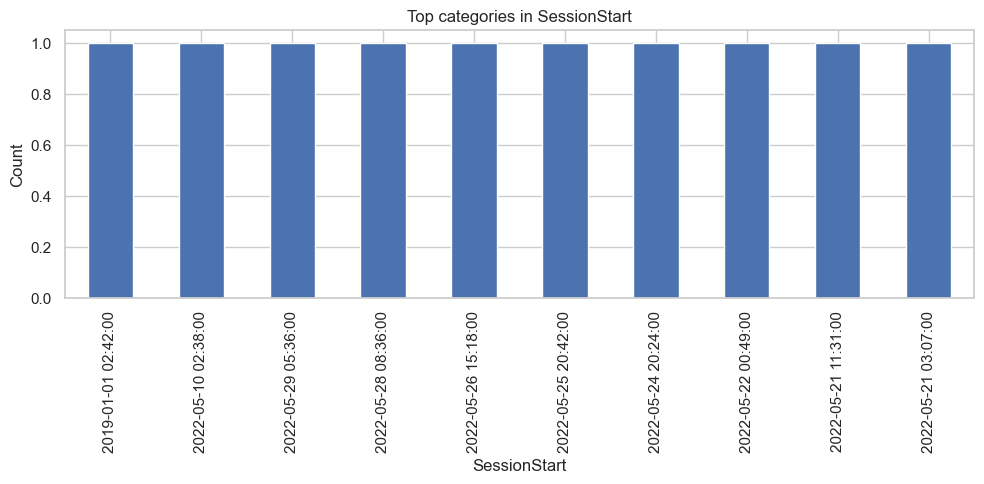

In [20]:
if categorical_cols:
    col = categorical_cols[0]
    plt.figure(figsize=(10, 5))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top categories in {col}")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

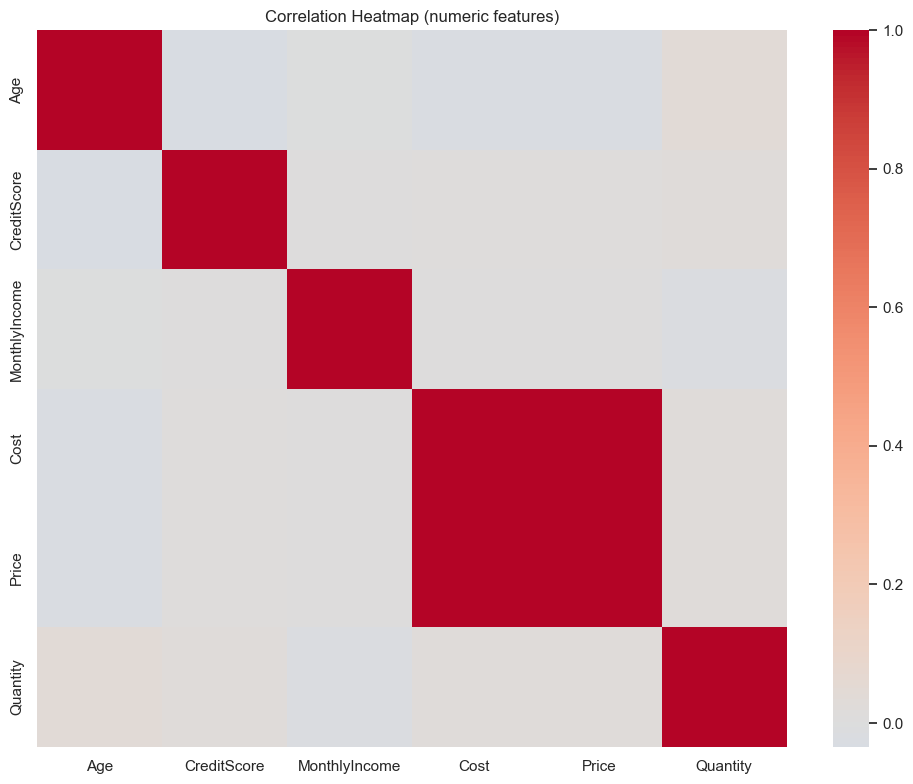

In [21]:
# correlations (numerical)
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap (numeric features)")
    plt.tight_layout()
    plt.show()

In [22]:
# example business style KPIs
# Example: if there's a revenue or amount column
for candidate in ["revenue", "amount", "sales", "total_spent", "purchase_value"]:
    if candidate in df.columns:
        revenue_col = candidate
        print("Using revenue column:", revenue_col)
        break
else:
    revenue_col = None
    print("No obvious revenue column found – adjust this logic once you inspect the data.")

No obvious revenue column found – adjust this logic once you inspect the data.


In [23]:
if revenue_col:
    print("Total revenue:", df[revenue_col].sum())
    print("Average revenue per record:", df[revenue_col].mean())
    print("Revenue quantiles:")
    display(df[revenue_col].quantile([0.25, 0.5, 0.75, 0.9, 0.95]))

In [24]:
for candidate in ["customer_id", "cust_id", "client_id", "user_id"]:
    if candidate in df.columns:
        customer_id_col = candidate
        print("Using customer ID column:", customer_id_col)
        break
else:
    customer_id_col = None
    print("No obvious customer ID column found – adjust once you inspect the data.")

if customer_id_col and revenue_col:
    customer_revenue = (
        df.groupby(customer_id_col)[revenue_col]
        .sum()
        .sort_values(ascending=False)
    )
    customer_revenue.head(10)

No obvious customer ID column found – adjust once you inspect the data.


OrderReturn
False    0.861176
True     0.138824
Name: proportion, dtype: float64


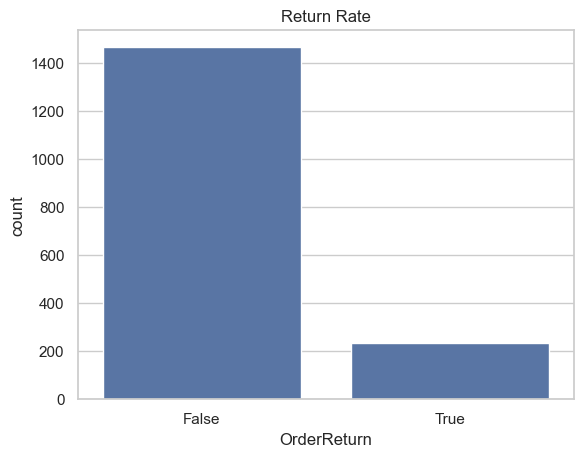

In [25]:
# Business EDA: return behavior
if "OrderReturn" in df.columns:
    print(df["OrderReturn"].value_counts(normalize=True))
    sns.countplot(data=df, x="OrderReturn")
    plt.title("Return Rate")
    plt.show()

In [26]:
# REvenue and margin metrics
df["Revenue"] = df["Price"] * df["Quantity"]
df["Margin"] = (df["Price"] - df["Cost"]) * df["Quantity"]

In [27]:
df.groupby("Category")["Revenue"].sum().sort_values(ascending=False).head(10)

Category
electronics        932140
home appliances    416110
fashion            101760
books               38421
toys                34080
Name: Revenue, dtype: int64

In [28]:
df.groupby("Product")["Revenue"].sum().sort_values(ascending=False).head(10)

Product
television        547500
laptop            357600
microwave oven    220000
electric stove    141600
shoes              41600
mixer grinder      32310
jeans              26740
dress              25920
toaster            22200
textbook           16750
Name: Revenue, dtype: int64

In [29]:
df["CampaignSchema"].nunique()

6

In [30]:
# Campaign performance
df.groupby("CampaignSchema")["Revenue"].sum().sort_values(ascending=False)

CampaignSchema
Instagram-ads        328177
Google-ads           267390
Billboard-QR code    258967
Facebook-ads         229802
Twitter-ads          227393
E-mails              210782
Name: Revenue, dtype: int64

In [31]:
df.groupby("CampaignSchema")["OrderReturn"].mean().sort_values()

CampaignSchema
Instagram-ads        0.116667
Twitter-ads          0.124528
E-mails              0.135531
Facebook-ads         0.142361
Billboard-QR code    0.151079
Google-ads           0.162162
Name: OrderReturn, dtype: object

In [32]:
# Customer lifetime value
clv = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
clv.head(10)

CustomerID
2163    12000
1278    10500
1687    10035
1079     9800
1496     9620
1990     9600
1171     9540
2193     9500
1739     9374
1969     9210
Name: Revenue, dtype: int64

In [33]:
# segment by income, location, etc.
df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

Country
Canada       192416
China        188607
Spain        179445
Italy        174219
Australia    171763
India        171417
USA          162879
Japan        162527
UK           119238
Name: Revenue, dtype: int64

In [34]:
# save a cleand/intermediate dataset
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "data")
os.makedirs(OUTPUT_DIR, exist_ok=True)

clean_path = os.path.join(OUTPUT_DIR, "customer_analytics_clean.csv")
df.to_csv(clean_path, index=False)
clean_path

'C:\\Users\\ynalq\\Projects\\Data-portfolio\\project8-agentic-customer-analytics-assistant\\data\\customer_analytics_clean.csv'